In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.io import imread
from skimage.restoration import rolling_ball
from os.path import join
import tifffile

dirpath      = r'E:\ND2\4_GFAP_IBA1\tiff_SC'
filename     = r'I61_SC_114_2_40X_1_loc01.tif'
filepath     = join(dirpath, filename)
img  = imread(filepath)

with tifffile.TiffFile(filepath) as tif:
    luts = tif.imagej_metadata['LUTs']

def lut_color(lut):
    r, g, b = lut[0].sum(), lut[1].sum(), lut[2].sum()
    if r == 0 and g > 0 and b > 0: return 'CYAN'   # GFAP 647
    elif r > 0 and g == 0 and b == 0: return 'Red'   # IBA1 555
    elif r == 0 and g > 0 and b == 0: return 'Green'
    elif r == 0 and g == 0 and b > 0: return 'BLUE' # DAPI
    else: return None

channel_colors = [lut_color(lut) for lut in luts]
print(channel_colors)

['Red', 'Green', 'CYAN', 'BLUE']


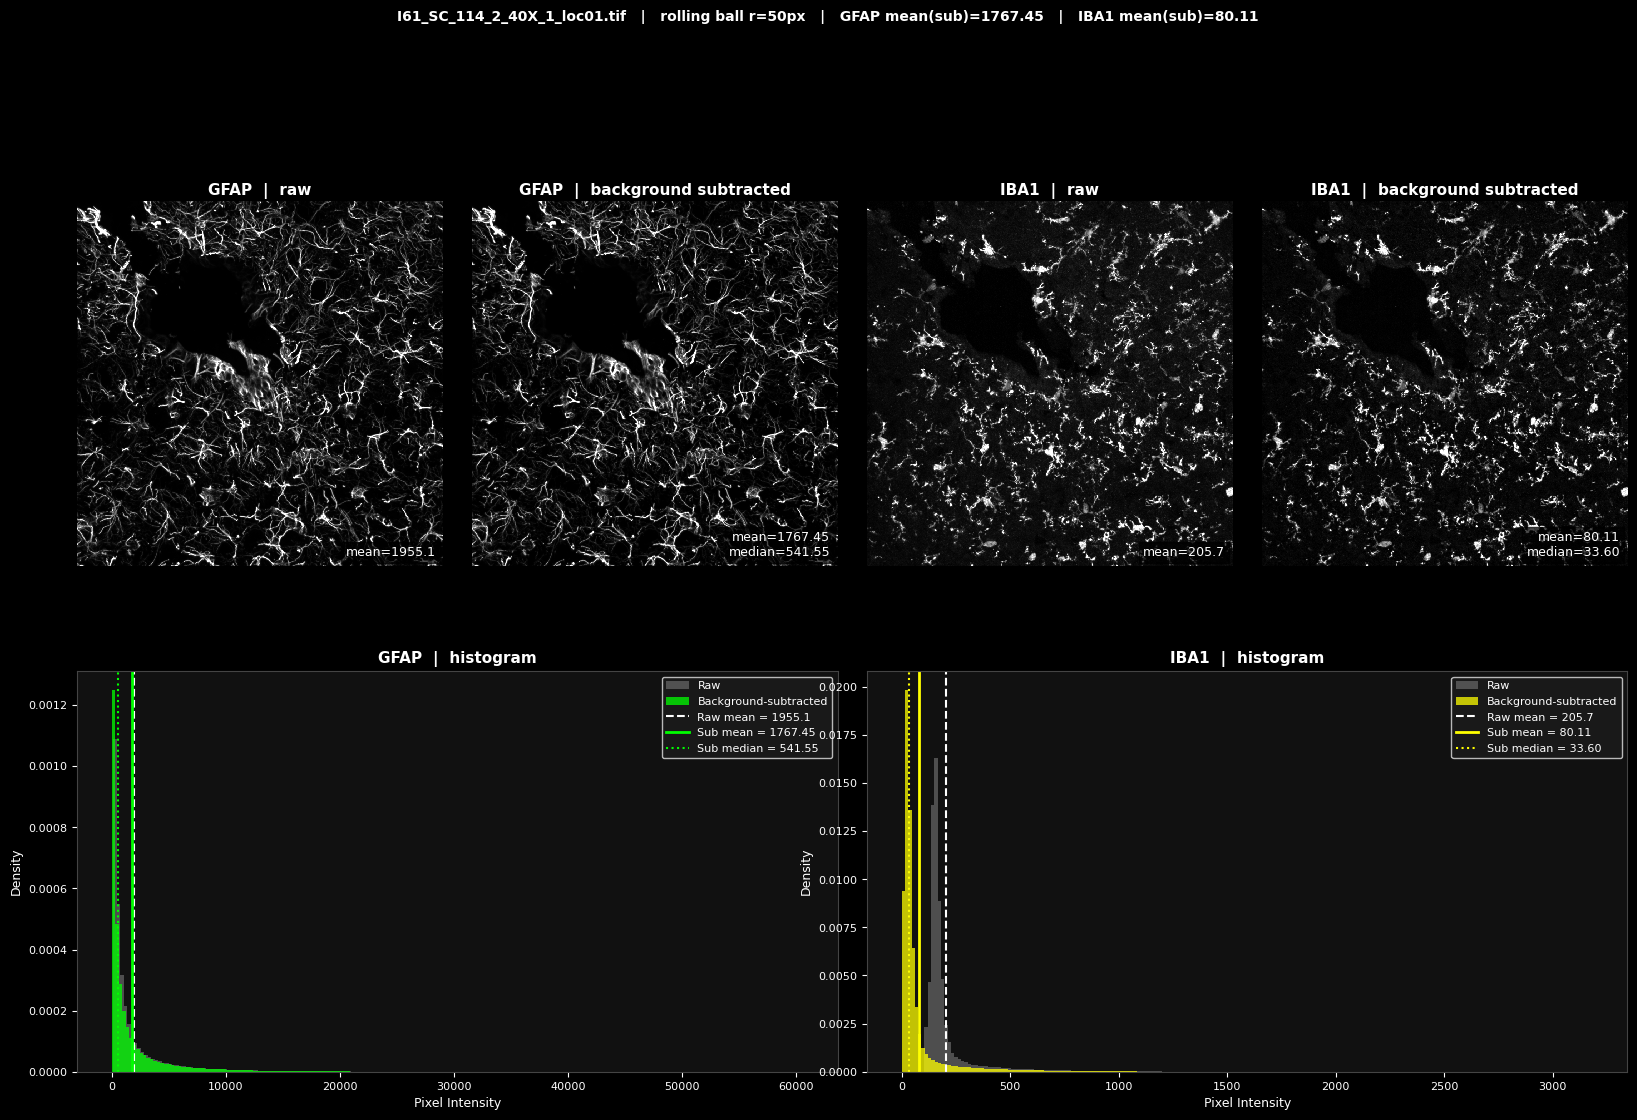


GFAP  raw=1955.1  sub_mean=1767.45  sub_median=541.55  ||  IBA1  raw=205.7  sub_mean=80.11  sub_median=33.60


In [2]:
GFAP_CHANNEL = channel_colors.index('CYAN')
IBA1_CHANNEL = channel_colors.index('Red')
BALL_RADIUS  = 50

gfap_raw = img[:, :, GFAP_CHANNEL].astype(np.float32)
iba1_raw = img[:, :, IBA1_CHANNEL].astype(np.float32)

# ─────────────────────────────────────────────
# ROLLING BALL BACKGROUND SUBTRACTION
# ─────────────────────────────────────────────
def subtract_background(channel, radius=50):
    background = rolling_ball(channel, radius=radius)
    subtracted = np.clip(channel - background, 0, None)
    return subtracted

gfap_sub = subtract_background(gfap_raw, BALL_RADIUS)
iba1_sub = subtract_background(iba1_raw, BALL_RADIUS)

def compute_stats(raw, subtracted):
    return {
        'mean_raw':    float(raw.mean()),
        'mean_sub':    float(subtracted.mean()),
        'median_sub':  float(np.median(subtracted)),
    }

g = compute_stats(gfap_raw, gfap_sub)
i = compute_stats(iba1_raw, iba1_sub)

# ─────────────────────────────────────────────
# FIGURE
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('black')
gs  = gridspec.GridSpec(2, 4, hspace=0.12, wspace=0.08,
                        height_ratios=[1, 0.85])

def styled_ax(ax):
    ax.set_facecolor('#111111')
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')
    return ax

for col_offset, (marker, raw, sub, stats, pos_color) in enumerate([
        ('GFAP', gfap_raw, gfap_sub, g, 'lime'),
        ('IBA1', iba1_raw, iba1_sub, i, 'yellow')]):

    c        = col_offset * 2
    vmin_raw = np.percentile(raw, 1)
    vmax_raw = np.percentile(raw, 99)
    vmin_sub = np.percentile(sub, 1)
    vmax_sub = np.percentile(sub, 99)

    # ── Raw image ──
    ax_raw = fig.add_subplot(gs[0, c])
    ax_raw.set_facecolor('black')
    ax_raw.imshow(raw, cmap='gray', interpolation='none', vmin=vmin_raw, vmax=vmax_raw)
    ax_raw.set_title(f'{marker}  |  raw', color='white', fontsize=11, fontweight='bold', pad=4)
    ax_raw.text(0.98, 0.02, f"mean={stats['mean_raw']:.1f}",
                transform=ax_raw.transAxes, fontsize=9, color='white',
                va='bottom', ha='right',
                bbox=dict(facecolor='black', alpha=0.7, pad=3))
    ax_raw.axis('off')

    # ── Background-subtracted image ──
    ax_sub = fig.add_subplot(gs[0, c+1])
    ax_sub.set_facecolor('black')
    ax_sub.imshow(sub, cmap='gray', interpolation='none', vmin=vmin_sub, vmax=vmax_sub)
    ax_sub.set_title(f'{marker}  |  background subtracted', color='white',
                     fontsize=11, fontweight='bold', pad=4)
    ax_sub.text(0.98, 0.02,
                f"mean={stats['mean_sub']:.2f}\nmedian={stats['median_sub']:.2f}",
                transform=ax_sub.transAxes, fontsize=9, color='white',
                va='bottom', ha='right',
                bbox=dict(facecolor='black', alpha=0.7, pad=3))
    ax_sub.axis('off')

    # ── Histogram ──
    ax_hist = styled_ax(fig.add_subplot(gs[1, c:c+2]))
    ax_hist.hist(raw.ravel(), bins=200, color='#777777', alpha=0.6,
                 label='Raw', density=True)
    ax_hist.hist(sub.ravel(), bins=200, color=pos_color, alpha=0.75,
                 label='Background-subtracted', density=True)
    ax_hist.axvline(stats['mean_raw'], color='white', linestyle='--', linewidth=1.5,
                    label=f"Raw mean = {stats['mean_raw']:.1f}")
    ax_hist.axvline(stats['mean_sub'], color=pos_color, linestyle='-', linewidth=2,
                    label=f"Sub mean = {stats['mean_sub']:.2f}")
    ax_hist.axvline(stats['median_sub'], color=pos_color, linestyle=':', linewidth=1.5,
                    label=f"Sub median = {stats['median_sub']:.2f}")
    ax_hist.set_xlabel('Pixel Intensity', color='white', fontsize=9)
    ax_hist.set_ylabel('Density',         color='white', fontsize=9)
    ax_hist.set_title(f'{marker}  |  histogram', color='white', fontsize=11, fontweight='bold')
    ax_hist.legend(fontsize=8, facecolor='#1a1a1a', labelcolor='white',
                   framealpha=0.9, loc='upper right')

fig.suptitle(
    f"{filename}   |   rolling ball r={BALL_RADIUS}px   |   "
    f"GFAP mean(sub)={g['mean_sub']:.2f}   |   "
    f"IBA1 mean(sub)={i['mean_sub']:.2f}",
    color='white', fontsize=10, fontweight='bold', y=0.995
)

out_path = join(dirpath, 'quantification.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

# ─────────────────────────────────────────────
# FINAL SUMMARY LINE
# ─────────────────────────────────────────────
print(f"{filename} ||  "
    f"\nGFAP  raw={g['mean_raw']:.1f}  sub_mean={g['mean_sub']:.2f}  sub_median={g['median_sub']:.2f}  ||  "
    f"IBA1  raw={i['mean_raw']:.1f}  sub_mean={i['mean_sub']:.2f}  sub_median={i['median_sub']:.2f}"
)

In [ ]:
# ─────────────────────────────────────────────
# STAGE 2: Threshold + masks
# ─────────────────────────────────────────────
thresh = threshold_otsu(gfap)
print(f"Otsu threshold: {thresh:.1f}  — override below if needed")
# thresh = 500  # ← uncomment and set manually if needed

signal_mask     = gfap > thresh
background_mask = ~signal_mask

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gfap, cmap='gray', interpolation='none')
axes[0].set_title('GFAP (gray)')
axes[1].imshow(signal_mask, cmap='Greens', interpolation='none')
axes[1].set_title(f'Signal mask (thresh={thresh:.0f})')
axes[2].imshow(background_mask, cmap='Purples', interpolation='none')
axes[2].set_title('Background mask')
for a in axes: a.axis('off')
plt.tight_layout()
plt.savefig('stage2_masks.png', dpi=150)
plt.show()


In [ ]:
# ─────────────────────────────────────────────
# STAGE 3: Erode masks (fixed deprecation)
# ─────────────────────────────────────────────
selem = disk(1)
signal_mask_eroded     = erosion(signal_mask.astype(np.uint8), selem).astype(bool)
background_mask_eroded = erosion(background_mask.astype(np.uint8), selem).astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(signal_mask_eroded, cmap='Greens', interpolation='none')
axes[0].set_title('Signal mask (eroded)')
axes[1].imshow(background_mask_eroded, cmap='Purples', interpolation='none')
axes[1].set_title('Background mask (eroded)')
for a in axes: a.axis('off')
plt.tight_layout()
plt.savefig('stage3_eroded_masks.png', dpi=150)
plt.show()


In [ ]:
# ─────────────────────────────────────────────
# STAGE 4: Sample ROIs — ensure full 5x5 fits inside mask
# ─────────────────────────────────────────────
ROI_SIZE = 5
N_SIGNAL = 5
N_BG     = 3

def sample_rois(mask, n, roi_size=5, seed=42):
    """
    Sample n ROI top-left corners where the ENTIRE roi_size x roi_size
    block is True in the mask.
    """
    h, w = mask.shape
    valid_ys, valid_xs = [], []

    # Only consider positions where full ROI block fits
    for y, x in zip(*np.where(mask)):
        if y + roi_size <= h and x + roi_size <= w:
            if mask[y:y+roi_size, x:x+roi_size].all():
                valid_ys.append(y)
                valid_xs.append(x)

    valid_ys = np.array(valid_ys)
    valid_xs = np.array(valid_xs)

    if len(valid_ys) == 0:
        raise ValueError("No valid ROI positions found — try lowering threshold or erosion size")

    rng = np.random.default_rng(seed)
    idx = rng.choice(len(valid_ys), size=min(n, len(valid_ys)), replace=False)
    return list(zip(valid_ys[idx], valid_xs[idx]))

def roi_mean(image, y, x, size=5):
    return image[y:y+size, x:x+size].mean()

signal_rois = sample_rois(signal_mask_eroded, N_SIGNAL, ROI_SIZE)
bg_rois     = sample_rois(background_mask_eroded, N_BG, ROI_SIZE)

signal_mfi = [roi_mean(gfap, y, x, ROI_SIZE) for y, x in signal_rois]
bg_mfi     = [roi_mean(gfap, y, x, ROI_SIZE) for y, x in bg_rois]

print(f"\nSignal ROI positions (y, x): {signal_rois}")
print(f"Background ROI positions:    {bg_rois}")
print(f"Signal MFIs:     {[f'{v:.1f}' for v in signal_mfi]}")
print(f"Background MFIs: {[f'{v:.1f}' for v in bg_mfi]}")


In [ ]:
# ─────────────────────────────────────────────
# STAGE 5: Overlay ALL ROIs clearly on image
# ─────────────────────────────────────────────
DISPLAY_ROI = 20   # display size in pixels for visibility (actual ROI is 5x5)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, title_suffix in zip(axes, ['Signal ROIs', 'Background ROIs']):
    ax.imshow(gfap, cmap='gray', interpolation='none', vmin=np.percentile(gfap, 1), vmax=np.percentile(gfap, 99))
    ax.axis('off')

# Left panel: signal ROIs
for i, (y, x) in enumerate(signal_rois):
    rect = mpatches.Rectangle((x - DISPLAY_ROI//2, y - DISPLAY_ROI//2),
                               DISPLAY_ROI, DISPLAY_ROI,
                               linewidth=2, edgecolor='lime', facecolor='lime', alpha=0.3)
    axes[0].add_patch(rect)
    rect2 = mpatches.Rectangle((x, y), ROI_SIZE, ROI_SIZE,
                                linewidth=2, edgecolor='lime', facecolor='none')
    axes[0].add_patch(rect2)
    axes[0].text(x + ROI_SIZE + 3, y + ROI_SIZE, f'S{i+1}\n{signal_mfi[i]:.0f}',
                 color='lime', fontsize=9, fontweight='bold',
                 bbox=dict(facecolor='black', alpha=0.5, pad=1))

axes[0].set_title(f'Signal ROIs (n={len(signal_rois)})  — green boxes', fontsize=12, color='white')
axes[0].set_facecolor('black')

# Right panel: background ROIs
for i, (y, x) in enumerate(bg_rois):
    rect = mpatches.Rectangle((x - DISPLAY_ROI//2, y - DISPLAY_ROI//2),
                               DISPLAY_ROI, DISPLAY_ROI,
                               linewidth=2, edgecolor='red', facecolor='red', alpha=0.3)
    axes[1].add_patch(rect)
    rect2 = mpatches.Rectangle((x, y), ROI_SIZE, ROI_SIZE,
                                linewidth=2, edgecolor='red', facecolor='none')
    axes[1].add_patch(rect2)
    axes[1].text(x + ROI_SIZE + 3, y + ROI_SIZE, f'B{i+1}\n{bg_mfi[i]:.0f}',
                 color='red', fontsize=9, fontweight='bold',
                 bbox=dict(facecolor='black', alpha=0.5, pad=1))

axes[1].set_title(f'Background ROIs (n={len(bg_rois)})  — red boxes', fontsize=12, color='white')
axes[1].set_facecolor('black')

fig.suptitle('Stage 5: Sampled ROIs (small box = actual 5×5 px ROI, halo = visual guide)',
             fontsize=11, color='white')
fig.patch.set_facecolor('black')
plt.tight_layout()
#plt.savefig('stage5_rois_overlay.png', dpi=150, facecolor='black')
plt.show()



In [ ]:
# ─────────────────────────────────────────────
# STAGE 6: Box plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 6))
data   = [signal_mfi, bg_mfi]
labels = ['GFAP Signal', 'Background']
colors = ['#cc44cc', '#888888']

bp = ax.boxplot(data, patch_artist=True, widths=0.4,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Individual points + mean line per group
for i, (vals, color) in enumerate(zip(data, colors), start=1):
    jitter = np.random.default_rng(0).uniform(-0.08, 0.08, len(vals))
    ax.scatter(np.array([i]*len(vals)) + jitter, vals,
               color='white', edgecolors=color, zorder=5, s=80, linewidths=1.5)
    ax.hlines(np.mean(vals), i - 0.2, i + 0.2,
              colors=color, linestyles='--', linewidth=2, label=f'Mean={np.mean(vals):.1f}')

ax.set_xticks([1, 2])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Mean Fluorescence Intensity (a.u.)', fontsize=11)
ax.set_title('GFAP MFI: Signal vs Background', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('stage6_mfi_boxplot.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────
df = pd.DataFrame({
    'ROI_type': ['Signal']*len(signal_mfi) + ['Background']*len(bg_mfi),
    'MFI':      signal_mfi + bg_mfi
})
print("\n── Summary ──")
print(df.groupby('ROI_type')['MFI'].describe().round(1))

In [ ]:
# ─────────────────────────────────────────────
# Prep ROI overlay images for figure
# ─────────────────────────────────────────────
DISPLAY_ROI = 20

def make_roi_overlay(base_img, rois, mfi_vals, color, roi_size=5, halo=20):
    """Returns figure axis content — drawn directly onto ax passed in."""
    return rois, mfi_vals

# Summary stats for header
mean_sig = np.mean(signal_mfi)
mean_bg  = np.mean(bg_mfi)
snr      = mean_sig / mean_bg if mean_bg > 0 else float('inf')
n_sig    = len(signal_mfi)
n_bg     = len(bg_mfi)

# ─────────────────────────────────────────────
# FINAL FIGURE
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 18))
fig.patch.set_facecolor('black')

gs = fig.add_gridspec(3, 3, hspace=0.05, wspace=0.05)
grid_positions = {
    'center': (1, 1),
    1: (0, 0),
    2: (0, 1),
    3: (0, 2),
    4: (1, 2),
    5: (2, 2),
    6: (2, 1),
    7: (2, 0),
    8: (1, 0),
}

label_color = '#99ccff'

def add_panel(ax, image, title_num=None, title_str=None, cmap='gray',
              vmin=None, vmax=None, overlay=None, overlay_cmap='prism', extra_text=None):
    ax.set_facecolor('black')
    ax.imshow(image, interpolation='none', cmap=cmap, vmin=vmin, vmax=vmax)
    if overlay is not None:
        ax.imshow(np.ma.array(overlay, mask=overlay == 0),
                  interpolation='none', cmap=overlay_cmap, alpha=0.6)
    if title_num is not None:
        ax.text(0.02, 0.98, f'{title_num}', transform=ax.transAxes,
                fontsize=16, color=label_color, fontweight='bold', va='top', ha='left')
    if title_str is not None:
        ax.text(0.5, 0.98, title_str, transform=ax.transAxes,
                fontsize=10, color='white', va='top', ha='center')
    if extra_text is not None:
        ax.text(0.98, 0.02, extra_text, transform=ax.transAxes,
                fontsize=10, color='white', va='bottom', ha='right')
    ax.axis('off')

# ── Center: raw GFAP ──
ax_c = fig.add_subplot(gs[1, 1])
ax_c.imshow(gfap, cmap='gray', interpolation='none',
            vmin=np.percentile(gfap, 1), vmax=np.percentile(gfap, 99))
ax_c.text(0.5, 0.98, 'RAW GFAP', transform=ax_c.transAxes,
          fontsize=14, color='white', va='top', ha='center', fontweight='bold')
ax_c.axis('off')

# ── 1: Signal mask ──
ax1 = fig.add_subplot(gs[grid_positions[1]])
add_panel(ax1, signal_mask.astype(float), cmap='Greens',
          title_num=1, title_str='Signal mask (Otsu)',
          extra_text=f'thresh={thresh:.0f}')

# ── 2: Background mask ──
ax2 = fig.add_subplot(gs[grid_positions[2]])
add_panel(ax2, background_mask.astype(float), cmap='Purples',
          title_num=2, title_str='Background mask')

# ── 3: Eroded signal mask ──
ax3 = fig.add_subplot(gs[grid_positions[3]])
add_panel(ax3, signal_mask_eroded.astype(float), cmap='Greens',
          title_num=3, title_str='Signal mask (eroded)')

# ── 4: Eroded background mask ──
ax4 = fig.add_subplot(gs[grid_positions[4]])
add_panel(ax4, background_mask_eroded.astype(float), cmap='Purples',
          title_num=4, title_str='Background mask (eroded)')

# ── 5: Signal ROIs overlaid ──
ax5 = fig.add_subplot(gs[grid_positions[5]])
ax5.set_facecolor('black')
ax5.imshow(gfap, cmap='gray', interpolation='none',
           vmin=np.percentile(gfap, 1), vmax=np.percentile(gfap, 99))
for i, (y, x) in enumerate(signal_rois):
    halo = mpatches.Rectangle((x - DISPLAY_ROI//2, y - DISPLAY_ROI//2),
                               DISPLAY_ROI, DISPLAY_ROI,
                               linewidth=0, facecolor='lime', alpha=0.2)
    box  = mpatches.Rectangle((x, y), ROI_SIZE, ROI_SIZE,
                               linewidth=2, edgecolor='lime', facecolor='none')
    ax5.add_patch(halo)
    ax5.add_patch(box)
    ax5.text(x + ROI_SIZE + 2, y + ROI_SIZE,
             f'S{i+1}\n{signal_mfi[i]:.0f}',
             color='lime', fontsize=8, fontweight='bold',
             bbox=dict(facecolor='black', alpha=0.5, pad=1))
ax5.text(0.02, 0.98, '5', transform=ax5.transAxes,
         fontsize=16, color=label_color, fontweight='bold', va='top')
ax5.text(0.5, 0.98, f'Signal ROIs (n={n_sig})',
         transform=ax5.transAxes, fontsize=10, color='white', va='top', ha='center')
ax5.axis('off')

# ── 6: Background ROIs overlaid ──
ax6 = fig.add_subplot(gs[grid_positions[6]])
ax6.set_facecolor('black')
ax6.imshow(gfap, cmap='gray', interpolation='none',
           vmin=np.percentile(gfap, 1), vmax=np.percentile(gfap, 99))
for i, (y, x) in enumerate(bg_rois):
    halo = mpatches.Rectangle((x - DISPLAY_ROI//2, y - DISPLAY_ROI//2),
                               DISPLAY_ROI, DISPLAY_ROI,
                               linewidth=0, facecolor='red', alpha=0.2)
    box  = mpatches.Rectangle((x, y), ROI_SIZE, ROI_SIZE,
                               linewidth=2, edgecolor='red', facecolor='none')
    ax6.add_patch(halo)
    ax6.add_patch(box)
    ax6.text(x + ROI_SIZE + 2, y + ROI_SIZE,
             f'B{i+1}\n{bg_mfi[i]:.0f}',
             color='red', fontsize=8, fontweight='bold',
             bbox=dict(facecolor='black', alpha=0.5, pad=1))
ax6.text(0.02, 0.98, '6', transform=ax6.transAxes,
         fontsize=16, color=label_color, fontweight='bold', va='top')
ax6.text(0.5, 0.98, f'Background ROIs (n={n_bg})',
         transform=ax6.transAxes, fontsize=10, color='white', va='top', ha='center')
ax6.axis('off')

# ── 7: Both ROI types together ──
ax7 = fig.add_subplot(gs[grid_positions[7]])
ax7.set_facecolor('black')
ax7.imshow(gfap, cmap='gray', interpolation='none',
           vmin=np.percentile(gfap, 1), vmax=np.percentile(gfap, 99))
for i, (y, x) in enumerate(signal_rois):
    ax7.add_patch(mpatches.Rectangle((x, y), ROI_SIZE, ROI_SIZE,
                  linewidth=2, edgecolor='lime', facecolor='lime', alpha=0.4))
for i, (y, x) in enumerate(bg_rois):
    ax7.add_patch(mpatches.Rectangle((x, y), ROI_SIZE, ROI_SIZE,
                  linewidth=2, edgecolor='red', facecolor='red', alpha=0.4))
sig_p = mpatches.Patch(color='lime', label='Signal')
bg_p  = mpatches.Patch(color='red',  label='Background')
ax7.legend(handles=[sig_p, bg_p], loc='lower right',
           fontsize=8, facecolor='black', labelcolor='white', framealpha=0.7)
ax7.text(0.02, 0.98, '7', transform=ax7.transAxes,
         fontsize=16, color=label_color, fontweight='bold', va='top')
ax7.text(0.5, 0.98, 'All ROIs', transform=ax7.transAxes,
         fontsize=10, color='white', va='top', ha='center')
ax7.axis('off')

# ── 8: Box plot ──
ax8 = fig.add_subplot(gs[grid_positions[8]])
ax8.set_facecolor('#111111')
data   = [signal_mfi, bg_mfi]
labels = ['Signal', 'Background']
colors = ['#44dd44', '#dd4444']

bp = ax8.boxplot(data, patch_artist=True, widths=0.4,
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(color='white'),
                 capprops=dict(color='white'),
                 flierprops=dict(markerfacecolor='white'))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

for i, (vals, color) in enumerate(zip(data, colors), start=1):
    jitter = np.random.default_rng(0).uniform(-0.08, 0.08, len(vals))
    ax8.scatter(np.array([i]*len(vals)) + jitter, vals,
                color='white', edgecolors=color, zorder=5, s=80, linewidths=1.5)
    ax8.hlines(np.mean(vals), i - 0.2, i + 0.2,
               colors=color, linestyles='--', linewidth=2)

ax8.set_xticks([1, 2])
ax8.set_xticklabels(labels, fontsize=10, color='white')
ax8.set_ylabel('MFI (a.u.)', fontsize=10, color='white')
ax8.tick_params(colors='white')
for spine in ax8.spines.values():
    spine.set_edgecolor('#444444')
ax8.text(0.02, 0.98, '8', transform=ax8.transAxes,
         fontsize=16, color=label_color, fontweight='bold', va='top')
ax8.text(0.5, 0.98, 'MFI Comparison', transform=ax8.transAxes,
         fontsize=10, color='white', va='top', ha='center')

# ── Suptitle with data summary ──
summary = (f'GFAP MFI  |  Signal: mean={mean_sig:.1f}  n={n_sig}    '
           f'Background: mean={mean_bg:.1f}  n={n_bg}    '
           f'SNR={snr:.2f}    Threshold={thresh:.0f}    File: {filename}')
plt.suptitle(summary, color='white', fontsize=11, fontweight='bold', y=0.998)

plt.savefig('pipeline_overview2.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()